In [93]:
# TODO do kind of radio-concentric, going through major roads and linking train stations

In [94]:
import os
import json
import osmnx as ox
from orderbike.growth import order_ranked_network_growth, compute_metrics

In [95]:
G = ox.load_graphml(
    "../data/processed/paris_simplified_results/paris_cleaned_multigraph.graphml"
)

In [96]:
edge_order = [
    (696, 697),  # first edge
    (63, 697),  # other side of Seine
    (63, 458),
    (458, 1059),
    (345, 1059),
    (61, 696),  # to Gare du Nord/ESt
    (61, 456),
    (456, 695),
    (695, 771),
    (771, 796),
    (420, 796),
    (420, 430),
    (345, 1061),  # to Denfert-Rochereau
    (405, 1061),
    (405, 1064),
    (1062, 1064),
    (1062, 1076),
    (227, 1076),
    (430, 508),  # finish north line
    (508, 839),
    (839, 962),
    (630, 962),
    (227, 413),  # finish south line
    (115, 413),
    (115, 411),
    (62, 63),  # to Gare de Lyon/Austerlitz
    (62, 390),
    (390, 403),
    (403, 438),
    (368, 438),
    (368, 370),
    (370, 402),
    (295, 402),
    (63, 64),  # to Eiffel Tower
    (64, 68),
    (68, 559),
    (530, 559),
    (52, 530),
    (52, 206),
    (41, 206),  # finish southwest line to final ring road
    (38, 41),
    (35, 38),
    (219, 295),  # finish southeast line to final ring road
    (219, 220),
    (220, 223),
    (300, 438),  # start ring to Bastille
    (559, 742),  # continue ring to Paris-Saint-Lazare
    (441, 742),
    (435, 441),
    (435, 436),
    (436, 437),
    (437, 750),
    (749, 750),
    (247, 749),  # finish north small ring part
    (247, 1069),
    (313, 1069),
    (187, 313),
    (187, 242),
    (242, 352),
    (352, 695),
    (446, 695),
    (444, 446),
    (58, 444),
    (58, 511),
    (510, 511),
    (502, 510),
    (300, 502),
    (76, 438),  # finish south small ring part
    (75, 76),
    (75, 346),
    (345, 346),
    (24, 345),
    (24, 344),
    (341, 344),
    (339, 341),
    (336, 339),
    (336, 559),
    (437, 586),  # go northwest to second ring road through Saint-Lazare
    (586, 770),
    (770, 1073),
    (782, 1073),
    # (738, 782),
    # (677, 738),
    # (794, 920), # Mistake in the network, should be connected but is not so removing all
    (58, 757),  # go west to final ring road through Republique
    (416, 757),
    (416, 496),
    (327, 496),
    (327, 455),
    (455, 488),
    (292, 488),
    (405, 607),  # go southwest to final ring road
    (602, 607),
    (79, 602),
    (78, 79),
    (1, 78),
    (0, 1),
    (0, 505),
    (371, 505),
    (227, 228),  # second ring road, go from Denfer to Montparnasse
    (32, 228),
    (32, 589),
    (9, 589),
    (226, 227),  # connect montparnasse to austerlitz/lyon
    (226, 1033),
    (620, 1033),
    (620, 621),
    (426, 621),
    (426, 638),
    (86, 638),
    (86, 219),
    (219, 289),
    (289, 305),
    (149, 305),  # connect lyon to est/nord/saint-lazare
    (149, 153),
    (153, 307),
    (198, 307),
    (128, 198),
    (128, 311),
    (212, 311),
    (212, 324),
    (324, 327),
    (316, 327),
    (314, 316),
    (150, 314),
    (150, 151),
    (151, 366),
    (366, 385),
    (103, 385),
    (103, 508),
    (249, 508),
    (249, 424),
    (179, 424),
    (122, 179),
    (30, 122),
    (30, 746),
    (739, 746),  # finish second ring road
    (739, 782),
    (1, 9),
    (1, 6),
    (6, 565),
    (560, 565),
    (41, 560),
    (49, 206),
    (49, 120),
    (102, 120),
    (102, 782),
    (300, 464),  # bastille to nation to final ring road
    (310, 464),
    (310, 311),
    (311, 787),
    (126, 787),
    (529, 742),  # through champs elysees to final ring road
    (529, 532),
    (120, 532),
    (120, 125),
    (405, 407),  # complete other southweast to final ring road
    (407, 408),
    (71, 408),
    (71, 399),
    (399, 426),
    (426, 434),
    (433, 434),
    (747, 749),  # saint-lazare to montmarte to final ring road
    (694, 747),
    (692, 694),
    (692, 708),
    (30, 708),
    (29, 30),
    (29, 263),
    (263, 624),
    (58, 1074),  # republique to final ring road northeast
    (758, 1074),
    (391, 758),
    (150, 391),
    (99, 314),
    (99, 486),
    (274, 486),
    (87, 274),
    (223, 960),  # final ring road, vincennes part
    (156, 960),
    (156, 202),
    (126, 202),
    (371, 814),  # final ring road, southwest to boulognes
    (619, 814),
    (550, 619),
    (550, 551),
    (35, 551),
    (35, 272),
    (272, 554),
    (334, 554),
    (334, 569),
    (569, 575),
    (575, 673),
    (350, 673),
    (350, 882),
    (123, 882),
    (123, 125),
    (57, 371),  # boulognes to vincennes
    (56, 57),
    (56, 610),
    (116, 610),
    (116, 411),
    (411, 720),
    (667, 720),
    (667, 669),
    (669, 674),
    (674, 675),
    (675, 709),
    (701, 709),
    (631, 701),
    (433, 631),
    (433, 722),
    (722, 736),
    (331, 736),
    (80, 331),
    (80, 223),
    (126, 215),  # finish ring road from east to north to west
    (215, 348),
    (348, 349),
    (292, 349),
    (292, 489),
    (87, 489),
    (87, 171),
    (166, 171),
    (166, 469),
    (357, 469),
    (357, 363),
    (363, 799),
    (364, 799),
    (364, 630),
    (628, 630),
    (626, 628),
    (625, 626),
    (624, 625),
    (624, 656),
    (656, 794),
    (793, 794),
    (55, 793),
    (55, 666),
    (666, 886),
    (849, 886),
    (125, 849),
]

In [97]:
# (168, 565), # connect second to small ring road southwest
# (162, 168),
# (162, 163),
# (163, 578),
# (20, 578),
# (20, 24)

In [98]:
edge_order = [(a, b, 0) for a, b in edge_order]

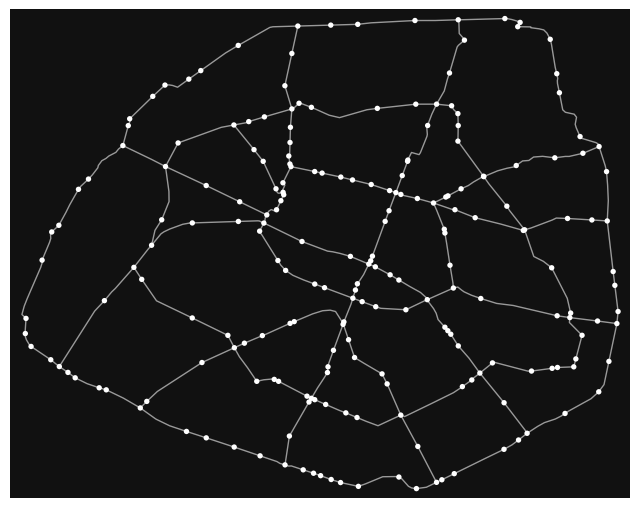

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [99]:
ox.plot_graph(G.edge_subgraph(edge_order))

In [100]:
edge_missing = [e for e in G.edges if e not in edge_order]

In [101]:
len(edge_missing)

465

In [102]:
H = G.copy()
for edge in H.edges:
    if edge in edge_order:
        H.edges[edge]["built"] = 1
    else:
        H.edges[edge]["built"] = 0

In [103]:
order_growth = order_ranked_network_growth(
    H,
    built=True,
    keep_connected=True,
    order="additive",
    save_metrics=False,
    buff_size_metrics=400,
)

In [104]:
full_order = edge_order + order_growth

In [105]:
full_order.pop(0)

(696, 697, 0)

In [106]:
foldername = "../data/processed/paris_simplified_results/No/manual"
if not os.path.exists(foldername):
    os.makedirs(foldername)

In [107]:
with open(foldername + "/order_growth.json", "w") as f:
    json.dump(full_order, f)

In [108]:
metrics_growth = compute_metrics(
    G,
    full_order,
    built=False,
    x_meter=True,
    buff_size=400,
)

In [109]:
with open(foldername + "/metrics_growth.json", "w") as f:
    json.dump(metrics_growth, f)